In [1]:
import pandas as pd

In [2]:
from sqlalchemy import create_engine

In [4]:
MYSQL_USER = "root"
MYSQL_PASS = "password"  
MYSQL_HOST = "localhost"
MYSQL_PORT = 3306
MYSQL_DB   = "retail"

In [5]:
engine = create_engine(
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASS}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DB}?charset=utf8mb4"
)

In [6]:
file_path = "downloads/online_retail_II.csv"
df = pd.read_csv(file_path)

In [7]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [8]:
df["Customer ID"] = df["Customer ID"].fillna("Unknown")

In [9]:
# Filter out the 'Unknown' customers
df_customers = df[df["Customer ID"] != "Unknown"]

In [10]:
df = df.drop_duplicates()

In [11]:
df = df[df["Quantity"] > 0]              # only positive sales
df = df[df["Price"] > 0]                 #only positive value

In [13]:
# Write into MySQL
df.to_sql("transactions", engine, if_exists="replace", index=False, chunksize=10000, method="multi")


1007914

In [ ]:
# Monthly Revenue Trend

In [14]:
query="""
SELECT DATE_FORMAT(InvoiceDate, '%%Y-%%m') AS month,
       ROUND(SUM(Quantity * Price), 2) AS revenue
FROM transactions
GROUP BY month
ORDER BY month;"""

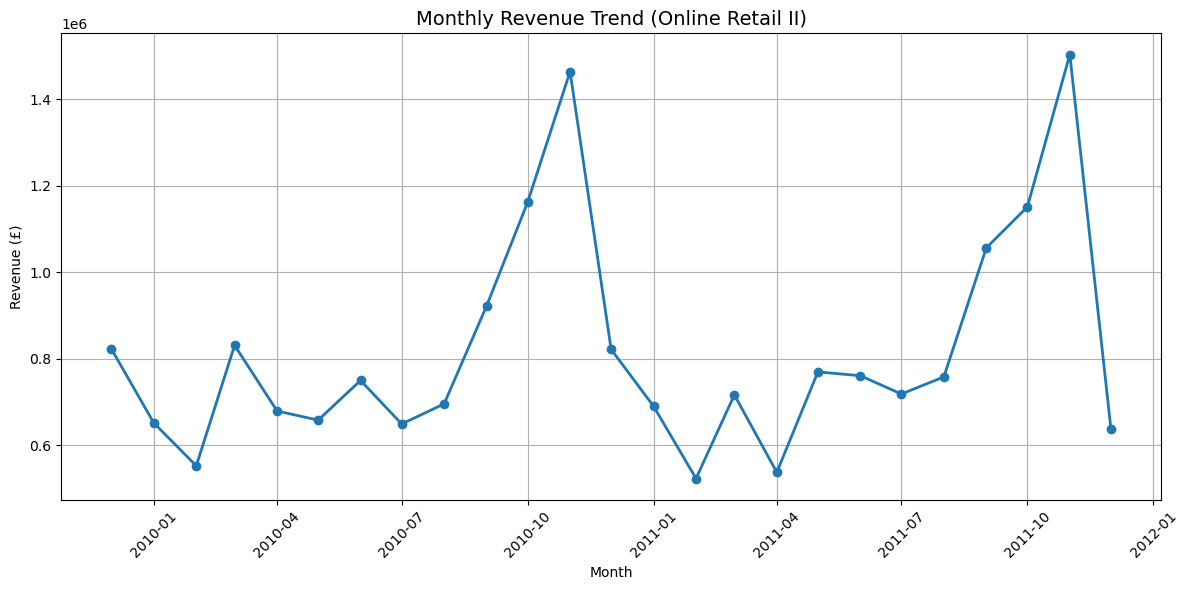

In [15]:
import matplotlib.pyplot as plt
df = pd.read_sql(query, engine)

# Convert month to datetime for plotting
df["month"] = pd.to_datetime(df["month"])

# --- Plot ---
plt.figure(figsize=(12,6))
plt.plot(df["month"], df["revenue"], marker='o', linestyle='-', linewidth=2)

plt.title("Monthly Revenue Trend (Online Retail II)", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# Show the chart
plt.show()

September to November is the most profitable period every year.

Company could plan:

More marketing & stock in September–November.

Special promotions in slow months (Jan–Feb) to boost sales.

In [17]:
#Top Countries (outside UK) by Revenue

In [18]:
query2 = """
SELECT Country,
       ROUND(SUM(Quantity * Price), 2) AS revenue
FROM transactions
WHERE Country <> 'United Kingdom'
GROUP BY Country
ORDER BY revenue DESC
LIMIT 10;
"""

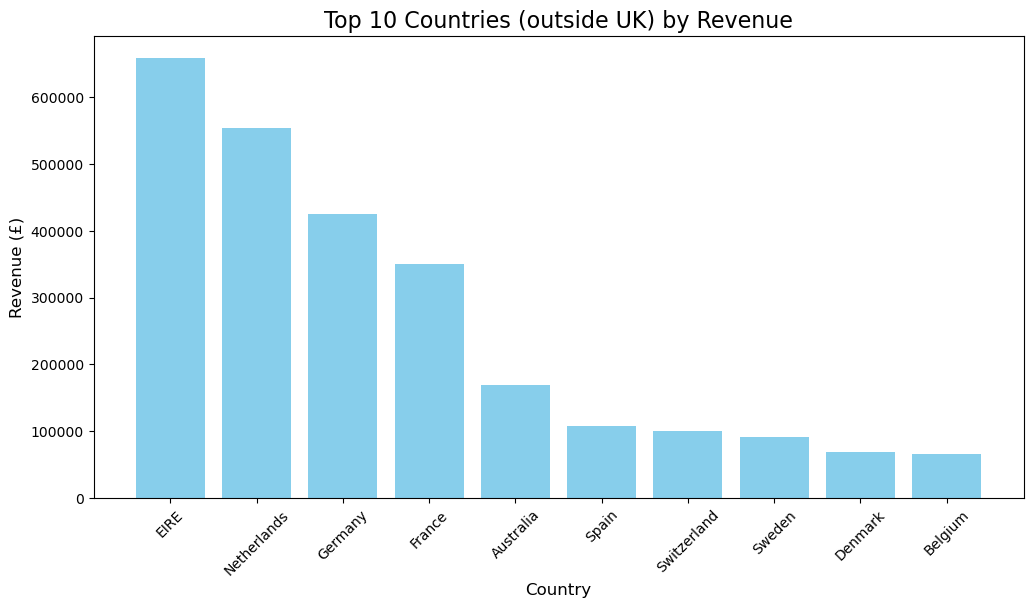

In [19]:
# Read query results into a pandas DataFrame
df_countries = pd.read_sql(query2, engine)

# Plot bar chart
plt.figure(figsize=(12,6))
plt.bar(df_countries['Country'], df_countries['revenue'], color='skyblue')
plt.title('Top 10 Countries (outside UK) by Revenue', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Revenue (£)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

EIRE, Netherlands, Germany, France, and Australia are the biggest contributors outside the UK.

Countries like Denmark, Belgium, and Switzerland contribute less but are still in the top 10.

In [22]:
#Top 10 Stock Codes by Quantity Sold

In [20]:
query3 = """
SELECT StockCode,
       SUM(Quantity) AS total_quantity
FROM transactions
GROUP BY StockCode
ORDER BY total_quantity DESC
LIMIT 10;
"""

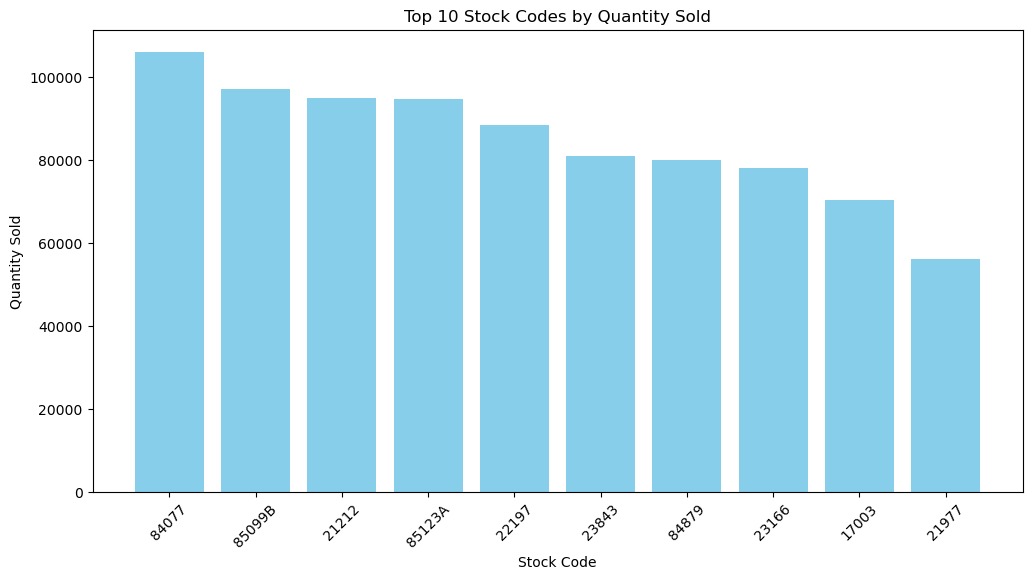

In [21]:
df_top_stock = pd.read_sql(query3, engine)

# Plot
plt.figure(figsize=(12,6))
plt.bar(df_top_stock["StockCode"], df_top_stock["total_quantity"], color='skyblue')
plt.title("Top 10 Stock Codes by Quantity Sold")
plt.xlabel("Stock Code")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.show()

The top-selling product is 84077 with 106,139 units, clearly outperforming others. Most sales are concentrated in a few products, suggesting a focus on these for inventory and promotions.